# V4-3-0 Inferencing — Diffusion Transformer Sampling

อัปเดตจาก `V3-3_Inferencing` ให้ตรงกับ pipeline ใหม่ (`v4-2-0_modeling`):
- โหลด feature store ด้วย `load_data` / `build_datasets` (utils/io.py, utils/datasets.py) แทน `load_variant` / `make_all_dataloaders`
- โมเดล `DiffusionTransformer` ใช้ tensor 4D `(B, W, A, C)` ตรง ๆ ไม่ต้อง flatten `(W, A) → Seq` แบบเดิม
- **เลือก split ได้** (`train` / `val` / `test`) สำหรับ inferencing
- ปกติคือ 1 window = 1 batch อยู่แล้ว → **ขยายเป็น N batch (`NUM_SIMULATIONS`)** ด้วยการ expand `cond` ตาม batch dim
- inverse scale ผลลัพธ์ → log return → cumsum + exp × init_price → ราคา (price)

# 1. Import & Config

In [1]:
import sys, os, json
import math
import random
import pandas as pd
import threading, time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from pathlib import Path
from tqdm.auto import tqdm

from config import (
    InferenceConfig,
    DDPMTransformerConfig,
    FMConfig,
)
from models import Diffusion, DiffusionTransformer, FlowMatching, DDIM
from utils import (
    setup_logging,
    setup_random_seed,
    load_data,
    build_datasets,
)
from utils.scaler import inverse_transform_windows_x, compute_start_indices
from utils.paths import PROCESSED_DIR, EXPERIMENTS_DIR

logger = setup_logging()
logger.info("✓ Imports OK")


2026-07-24 18:10:53,952 - utils.setup - INFO - Logger is set up.
2026-07-24 18:10:53,953 - utils.setup - INFO - ✓ Imports OK


## 1.1 Config (UI)

In [2]:
# ── ระบุแค่ "ใช้ experiment ไหน" (group/subgroup/experiment_name = ที่ใช้หา experiment_dir) ──
# ที่เหลือทั้งหมด (processed_*, model_params) จะถูกอ่านจาก
# experiment_dir/experiment_config.json ของ experiment นั้นโดยตรง — single source of truth
# ไม่ต้องมานั่งกรอกซ้ำเอง (กรอกผิด/ไม่ตรงกับตอนเทรนจริงจะ load checkpoint ไม่เข้า)
cfg = InferenceConfig(
    name             = "inference_config",
    # group            = "set_index",       # = group_name ตอนเทรน
    # subgroup         = "set_idx50",       # = subgroup_name ตอนเทรน
    # experiment_name  = "v1_trial01_w20a33_ddpm_warmup-cosine_annaul",
    # experiment_name  = "v1_trial01_w20a33_ddpm_warmup-cosine_optuna",
    # checkpoint_file  = "epoch_1000.pt",
    group            = "sp_index",
    subgroup         = "sp_idx100",
    experiment_name  = "v1_trial01_w20a88_ddpm_warmup-cosine_optuna",
    checkpoint_file  = "best_model.pt",
    num_simulations  = 100,
    random_seed      = 72,
)
cfg.device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

# โหลด processed_group_name / processed_subgroup_name / processed_name + model_params
# จาก cfg.experiment_dir / "experiment_config.json" ของ experiment นี้
cfg = cfg.apply_experiment_config()

# ── Inference-only settings ─────────────────────────────────────────
SPLIT            = "train"       # เลือกได้: "train" | "val" | "test"
WINDOW_IDX       = None         # None → สุ่มเลือก window ใน split นั้น, หรือใส่ index ตรง ๆ
RANDOM_SEED      = 72
CLOSE_FEATURE    = "Close"      # ชื่อ channel ที่ใช้ reconstruct ราคา

assert SPLIT in ("train", "val", "test"), f"Unknown split: {SPLIT}"

setup_random_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

[InferenceConfig] model_params loaded from best_params.json


In [3]:
print("=" * 60)
print("  V4-3-0 INFERENCING")
print("=" * 60)
print(f"  Experiment       : {cfg.experiment_name}")
print(f"  Processed dir    : {cfg.processed_dir}")
print(f"  Checkpoint path  : {cfg.checkpoint_path}")
print(f"  Split            : {SPLIT}")
print(f"  Window idx       : {'random' if WINDOW_IDX is None else WINDOW_IDX}")
print(f"  Num simulations  : {cfg.num_simulations}")
print(f"  Device           : {cfg.device}")
print(f"  Random seed      : {RANDOM_SEED}")
print("=" * 60)

  V4-3-0 INFERENCING
  Experiment       : v1_trial01_w20a88_ddpm_warmup-cosine_optuna
  Processed dir    : /home/narodom.y@FUSION.LAB/research/01_processed/sp_index/sp_idx100/trial01_w20_assets88_scaler-x_standard_scaler-condrobust
  Checkpoint path  : /home/narodom.y@FUSION.LAB/research/02_experiments/sp_index/sp_idx100/v1_trial01_w20a88_ddpm_warmup-cosine_optuna/checkpoints/best_model.pt
  Split            : train
  Window idx       : random
  Num simulations  : 100
  Device           : cuda:1
  Random seed      : 72


# 2. Load Feature Store & Build Model

In [4]:
loaded   = load_data(str(cfg.processed_dir))
datasets = build_datasets(loaded)

tickers       = loaded["tickers"]
features_lr   = loaded["features_lr"]
features_cond = loaded["features_cond"]
scalers_x     = loaded["scalers_x"]
scalers_cond  = loaded["scalers_cond"]

CLOSE_IDX = features_lr.index(CLOSE_FEATURE)

print(f"tickers      : {tickers}")
print(f"features_lr  : {features_lr}")
print(f"close idx    : {CLOSE_IDX}")
for s in ("train", "val", "test"):
    print(f"  {s:<6} n_windows={len(datasets[s])}")

tickers      : ['AAPL', 'ABT', 'ACN', 'ADBE', 'AIG', 'ALL', 'AMGN', 'AMZN', 'AXP', 'BA', 'BAC', 'BIIB', 'BK', 'BKNG', 'BLK', 'BMY', 'C', 'CAT', 'CHTR', 'CL', 'CMCSA', 'COF', 'COP', 'COST', 'CSCO', 'CVS', 'CVX', 'DHR', 'DIS', 'DUK', 'EMR', 'EXC', 'F', 'FDX', 'GD', 'GE', 'GILD', 'GOOG', 'GOOGL', 'GS', 'HAL', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KMB', 'KO', 'LLY', 'LMT', 'LOW', 'MA', 'MCD', 'MDT', 'MET', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'NEE', 'NFLX', 'NKE', 'NVDA', 'ORCL', 'OXY', 'PEP', 'PFE', 'PG', 'PM', 'QCOM', 'SBUX', 'SLB', 'SO', 'SPG', 'T', 'TGT', 'TXN', 'UNH', 'UNP', 'UPS', 'USB', 'V', 'VZ', 'WFC', 'WMT', 'XOM']
features_lr  : ['Close', 'High', 'Low', 'Open']
close idx    : 0
  train  n_windows=2004
  val    n_windows=246
  test   n_windows=996


## 2.1 Build model

In [5]:
# import json
# best_params_path = cfg.experiment_dir / "optuna" / "best_params.json"
# with open(best_params_path) as f:
#     best = json.load(f)
# print(best)

# from dataclasses import replace
# cfg.model_params = replace(cfg.model_params, d_model=256)

In [6]:
def build_model(exp_cfg, input_dim: int, cond_dim: int) -> nn.Module:
    """
    Build model จาก input_dim/cond_dim ตรง ๆ — เหมือนกับใน v4-2-0_modeling
    (ไม่มี seq_dims/feat_dims อีกแล้ว เพราะ DiffusionTransformer กิน (B, W, A, C) ตรง ๆ)
    architecture params มาจาก exp_cfg.model_params (โหลดจาก experiment_config.json จริงของ checkpoint นั้น)
    """
    m = exp_cfg.model_params

    if isinstance(m, DDPMTransformerConfig):
        backbone = DiffusionTransformer(
            input_dim            = input_dim,
            cond_dim             = cond_dim,
            d_model              = m.d_model,
            num_layers           = m.num_layers,
            num_attention_heads  = m.num_attention_heads,
            dim_feedforward      = m.dim_feedforward,
            dropout              = m.dropout,
        )
        model = DDIM(
            model      = backbone,
            timesteps  = m.timesteps,
            beta_start = m.beta_start,
            beta_end   = m.beta_end,
        ).to(exp_cfg.device)

    elif isinstance(m, FMConfig):
        model = FlowMatching(cfg=m).to(exp_cfg.device)

    else:
        raise ValueError(f"Unknown model config: {type(m)}")

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Model     : {m.name}")
    print(f"  input_dim : {input_dim}")
    print(f"  cond_dim  : {cond_dim}")
    print(f"  Params    : {n_params:,}")
    return model


# x: (W, A, C_x)   cond: (W, A, C_c)
sample0   = datasets[SPLIT][0]
W, A, C_x = sample0["x"].shape
_, _, C_c = sample0["cond"].shape

input_dim = C_x
cond_dim  = C_c

print(f"  W={W}  A={A}  C_x={C_x}  C_c={C_c}")

model = build_model(cfg, input_dim=input_dim, cond_dim=cond_dim)

  W=20  A=88  C_x=4  C_c=21


/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


  Model     : ddpm_transformer
  input_dim : 4
  cond_dim  : 21
  Params    : 2,186,372


## 2.2 Load checkpoint

In [7]:
ckpt_path = cfg.checkpoint_path
print(f"  Loading checkpoint: {ckpt_path}")

ckpt = torch.load(ckpt_path, map_location=cfg.device)
# model.load_state_dict(ckpt["model_state_dict"])
incompatible = model.load_state_dict(ckpt["model_state_dict"], strict=False)
# แสดงว่า skip อะไรบ้าง (ควรเห็นแค่ alphas_hat_prev)
if incompatible.missing_keys:
    print(f"  [strict=False] missing keys (skipped): {incompatible.missing_keys}")
if incompatible.unexpected_keys:
    print(f"  [strict=False] unexpected keys (ignored): {incompatible.unexpected_keys}")
model.eval()

val_loss = ckpt.get("val_loss")
try:
    val_loss_str = f"{val_loss:.6f}"
except (TypeError, ValueError):
    val_loss_str = str(val_loss)

print(f"  ✓ Checkpoint loaded  (epoch={ckpt.get('epoch', '?')}  val_loss={val_loss_str})")

  Loading checkpoint: /home/narodom.y@FUSION.LAB/research/02_experiments/sp_index/sp_idx100/v1_trial01_w20a88_ddpm_warmup-cosine_optuna/checkpoints/best_model.pt
  ✓ Checkpoint loaded  (epoch=181  val_loss=0.206559)


/tmp/ipykernel_167560/370110496.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=cfg.device)


# 3. Log Returns → Price — reconstruct_prices definition

In [8]:
def reconstruct_prices(log_returns: np.ndarray, init_price: np.ndarray, close_idx: int) -> np.ndarray:
    """
    log_returns : (..., W, A, C_x)
    init_price  : (A, C_x)  — ราคาจริงก่อน window เริ่ม (จาก WindowDataset)
    return      : (..., W, A)  — close price ตาม window step, broadcast leading dims ใด ๆ ได้
    """
    lr_close = log_returns[..., close_idx]       # (..., W, A)
    cum      = np.cumsum(lr_close, axis=-2)       # cumsum ไปตามแกน W
    init     = init_price[:, close_idx]           # (A,)
    shape    = (1,) * (cum.ndim - 1) + (init.shape[0],)
    prices   = init.reshape(shape) * np.exp(cum)
    return prices

print("  ✓ reconstruct_prices defined")

  ✓ reconstruct_prices defined


# 4. Select Window & Simulate

In [9]:
SIM_MODE = "strided"    # ← เปลี่ยนตรงนี้: "single" | "full" | "strided"

# ── config เฉพาะของแต่ละ mode ─────────────────────────────────
SINGLE_WINDOW_IDX  = None   # None → สุ่ม, หรือใส่ int ตรง ๆ เช่น 42
STRIDED_WINDOW_W   = W      # stride = W (non-overlapping), หรือตัวเลขอื่น

# ── validate ──────────────────────────────────────────────────
assert SIM_MODE in ("single", "full", "strided"), \
    f"SIM_MODE ต้องเป็น 'single' | 'full' | 'strided', ได้: {SIM_MODE!r}"

ds        = datasets[SPLIT]
n_windows = len(ds)
dates     = loaded["splits"][SPLIT]["dates"]

if SIM_MODE == "single":
    if SINGLE_WINDOW_IDX is None:
        _w = random.randint(0, n_windows - 1)
    else:
        assert 0 <= SINGLE_WINDOW_IDX < n_windows, \
            f"SINGLE_WINDOW_IDX={SINGLE_WINDOW_IDX} out of range [0, {n_windows-1}]"
        _w = SINGLE_WINDOW_IDX
    window_idxs = [_w]
    print(f"  MODE : single window")
    print(f"  idx  : {_w}  (date={dates[_w]})")

elif SIM_MODE == "full":
    window_idxs = list(range(n_windows))
    print(f"  MODE : full split ({SPLIT})")
    print(f"  windows : {n_windows}")

elif SIM_MODE == "strided":
    stride      = max(1, STRIDED_WINDOW_W)
    window_idxs = list(range(0, n_windows, stride))
    print(f"  MODE : strided (stride={stride}, W={W})")
    print(f"  windows total   : {n_windows}")
    print(f"  windows to run  : {len(window_idxs)}")

print(f"  split           : {SPLIT}")
print(f"  num_simulations : {cfg.num_simulations}")

  MODE : strided (stride=20, W=20)
  windows total   : 2004
  windows to run  : 101
  split           : train
  num_simulations : 100


In [10]:
_dates_for_split = {
    s: loaded["splits"][s]["dates"]
    for s in ("train", "val", "test")
}
_window_size   = loaded["meta"]["config"]["window_size"]
_window_stride = loaded["meta"]["config"].get("window_stride", 1)

start_indices_by_split = {
    s: compute_start_indices(
        pd.DatetimeIndex(_dates_for_split[s].astype("datetime64[ns]")),
        _window_size,
        _window_stride,
    )
    for s in ("train", "val", "test")
}
print("  ✓ start_indices computed for all splits")


  ✓ start_indices computed for all splits


## 4.1 mc_simulate — Loop ทั้ง split

In [11]:
@torch.no_grad()
def mc_simulate(model, cond_w: torch.Tensor, n_sims: int, device) -> torch.Tensor:
    """
    cond_w : (W, A, C_c)  — window เดียว (scaled)
    return : (N, W, A, C_x)  — x ที่ generate (scaled), N = n_sims
    """
    W, A, C_c = cond_w.shape
    cond_batch = cond_w.unsqueeze(0).expand(n_sims, -1, -1, -1).contiguous().to(device)
    output_shape = (n_sims, W, A, input_dim)
    x_gen = model.sample(
        x_cond       = cond_batch,
        output_shape = output_shape,
        ddim_steps   = 50,    # ← ปรับได้ 20–200
        eta          = 0.0,   # ← 0 = deterministic
    )
    return x_gen

In [12]:
all_prices_gen   = []
all_prices_real  = []
all_log_ret_gen  = []
all_log_ret_real = []
all_dates        = []
skipped          = []

torch.cuda.reset_peak_memory_stats(cfg.device)

desc = {
    "single" : f"MC single (w={window_idxs[0]})",
    "full"   : f"MC full [{SPLIT}]",
    "strided": f"MC strided [{SPLIT}] stride={stride if SIM_MODE=='strided' else '-'}",
}[SIM_MODE]

start_indices = start_indices_by_split[SPLIT]   # (N_split,)

for w_idx in tqdm(window_idxs, desc=desc):
    sample       = ds[w_idx]
    cond_w       = sample["cond"]           # (W, A, C_c)
    x_real_w     = sample["x"]             # (W, A, C_x)
    init_price_w = sample["init_price"]    # (A, C_x)

    # simulate
    try:
        x_gen = mc_simulate(model, cond_w, cfg.num_simulations, cfg.device)
    except Exception as e:
        skipped.append((w_idx, f"simulate error: {e}"))
        continue

    # sanity check
    if torch.isnan(x_gen).any() or torch.isinf(x_gen).any():
        skipped.append((w_idx, "nan/inf in x_gen"))
        continue

    # ── seasonal start index ของ window นี้ ──────────────────────────────
    # start_indices[w_idx] = seasonal position ของ row แรกของ window w_idx
    # reshape เป็น (1,) เพื่อส่งเข้า inverse_transform_windows_x (รับ shape (N,))
    win_start = start_indices[w_idx : w_idx + 1]   # (1,)  ← seasonal index

    # inverse scale → log returns
    x_gen_np  = x_gen.cpu().numpy()                           # (N, W, A, C_x)
    x_real_np = x_real_w.unsqueeze(0).numpy()                # (1, W, A, C_x)

    lr_gen  = inverse_transform_windows_x(
        x_gen_np,
        scalers_x,
        tickers,
        start_indices=np.repeat(win_start, cfg.num_simulations),  # (N,) — same window, N sims
    )
    lr_real = inverse_transform_windows_x(
        x_real_np,
        scalers_x,
        tickers,
        start_indices=win_start,   # (1,)
    )[0]   # (W, A, C_x)

    # reconstruct prices
    init_np       = init_price_w.numpy()
    prices_gen_w  = reconstruct_prices(lr_gen,  init_np, CLOSE_IDX)   # (N, W, A)
    prices_real_w = reconstruct_prices(lr_real, init_np, CLOSE_IDX)   # (W, A)

    all_prices_gen.append(prices_gen_w)
    all_prices_real.append(prices_real_w)
    all_log_ret_gen.append(lr_gen)
    all_log_ret_real.append(lr_real)
    all_dates.append(dates[w_idx])

peak_gb = torch.cuda.max_memory_allocated(cfg.device) / 1024**3
n_ok    = len(all_dates)
n_run   = len(window_idxs)

print(f"\n  ✓ done — {n_ok}/{n_run} windows OK  |  skipped: {len(skipped)}")
print(f"  VRAM peak: {peak_gb:.3f} GB")
if skipped:
    print("  Skipped:")
    for idx, reason in skipped:
        print(f"    w={idx:>4}  {reason}")

# ── ถ้า single mode → print summary เพิ่มเติม ────────────────
if SIM_MODE == "single" and n_ok > 0:
    print(f"\n  Single window summary:")
    print(f"    window idx : {window_idxs[0]}")
    print(f"    date       : {all_dates[0]}")
    print(f"    prices_gen : {all_prices_gen[0].shape}   (N, W, A)")
    print(f"    prices_real: {all_prices_real[0].shape}  (W, A)")

MC strided [train] stride=20:   0%|          | 0/101 [00:00<?, ?it/s]


  ✓ done — 101/101 windows OK  |  skipped: 0
  VRAM peak: 1.320 GB


# 5. Stack Results

In [13]:
# Stack per-window lists → arrays
# shapes:
#   prices_gen_all   : (n_ok, N, W, A)
#   prices_real_all  : (n_ok, W, A)
#   log_ret_gen_all  : (n_ok, N, W, A, C_x)
#   log_ret_real_all : (n_ok, W, A, C_x)

prices_gen_all   = np.stack(all_prices_gen,   axis=0)   # (n_ok, N, W, A)
prices_real_all  = np.stack(all_prices_real,  axis=0)   # (n_ok, W, A)
log_ret_gen_all  = np.stack(all_log_ret_gen,  axis=0)   # (n_ok, N, W, A, C_x)
log_ret_real_all = np.stack(all_log_ret_real, axis=0)   # (n_ok, W, A, C_x)
dates_all        = np.array(all_dates)                  # (n_ok,)

print(f"  prices_gen_all   : {prices_gen_all.shape}")
print(f"  prices_real_all  : {prices_real_all.shape}")
print(f"  log_ret_gen_all  : {log_ret_gen_all.shape}")
print(f"  log_ret_real_all : {log_ret_real_all.shape}")
print(f"  dates_all        : {dates_all.shape}")


  prices_gen_all   : (101, 100, 20, 88)
  prices_real_all  : (101, 20, 88)
  log_ret_gen_all  : (101, 100, 20, 88, 4)
  log_ret_real_all : (101, 20, 88, 4)
  dates_all        : (101,)


## 5.1 Save — result_all_windows.npz

In [14]:
sim_dir = cfg.experiment_dir / "simulations" / f"{SPLIT}_all_n{cfg.num_simulations}"
sim_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    sim_dir / "result_all_windows.npz",
    prices_gen    = prices_gen_all,
    prices_real   = prices_real_all,
    log_ret_gen   = log_ret_gen_all,
    log_ret_real  = log_ret_real_all,
    dates         = dates_all,
    tickers       = np.array(tickers),
    skipped_idx   = np.array([s[0] for s in skipped]),
)
print(f"  ✓ saved → {sim_dir / 'result_all_windows.npz'}")


  ✓ saved → /home/narodom.y@FUSION.LAB/research/02_experiments/sp_index/sp_idx100/v1_trial01_w20a88_ddpm_warmup-cosine_optuna/simulations/train_all_n100/result_all_windows.npz


# 6. Plot — Price Fan Chart (single-window reference)

ใช้ window แรกใน `all_*` เป็นตัวอย่าง — เหมือนกับ single-window mode เดิม

  ✓ saved → /home/narodom.y@FUSION.LAB/research/02_experiments/sp_index/sp_idx100/v1_trial01_w20a88_ddpm_warmup-cosine_optuna/simulations/train_all_n100/price_fan_chart_w0.png


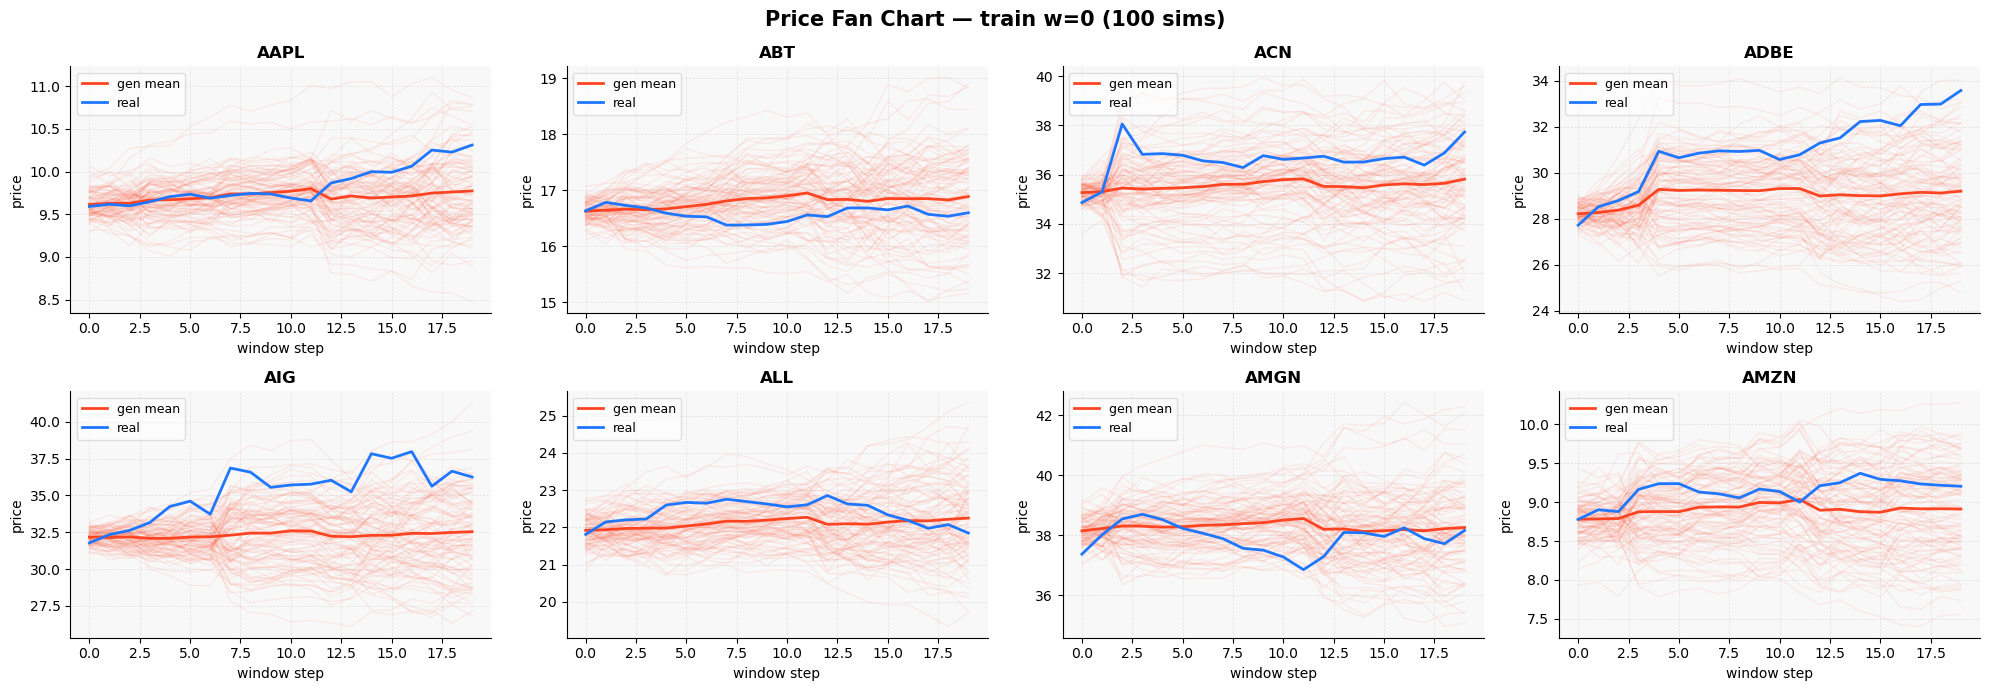

In [15]:
def plot_price_fan(prices_gen, prices_real, tickers, n_show=8, ncols=4, title="", save_path=None):
    """
    prices_gen  : (N, W, A)
    prices_real : (W, A)
    """
    A = prices_real.shape[-1]
    n_show = min(n_show, A)
    nrows  = math.ceil(n_show / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5))
    axes = np.atleast_1d(axes).flatten()

    for i in range(n_show):
        ax  = axes[i]
        sym = tickers[i] if i < len(tickers) else f"Asset {i}"

        for n in range(prices_gen.shape[0]):
            ax.plot(prices_gen[n, :, i], color="#ff4422", alpha=0.08, lw=1.0)

        ax.plot(prices_gen[:, :, i].mean(axis=0), color="#ff4422", lw=2.0, label="gen mean")
        ax.plot(prices_real[:, i], color="#1f77ff", lw=2.0, label="real")

        ax.set_title(sym, fontsize=12, fontweight="bold")
        ax.set_xlabel("window step", fontsize=10)
        ax.set_ylabel("price", fontsize=10)
        ax.legend(fontsize=9, framealpha=0.6)
        ax.set_facecolor("#f8f8f8")
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5, color="#cccccc")
        ax.spines[["top", "right"]].set_visible(False)

    for j in range(n_show, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=15, fontweight="bold")
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  ✓ saved → {save_path}")
    plt.show()


# แสดง window แรกที่ผ่าน sanity check เป็น reference
plot_price_fan(
    prices_gen_all[0], prices_real_all[0], tickers,
    n_show    = min(8, len(tickers)),
    title     = f"Price Fan Chart — {SPLIT} w=0 ({cfg.num_simulations} sims)",
    save_path = sim_dir / "price_fan_chart_w0.png",
)


# 7. Plot — Log-Return Distribution

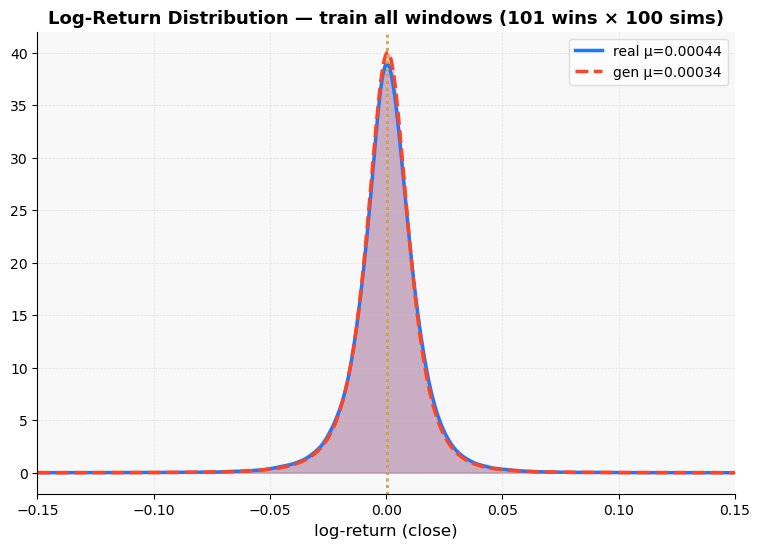

  ✓ saved → /home/narodom.y@FUSION.LAB/research/02_experiments/sp_index/sp_idx100/v1_trial01_w20a88_ddpm_warmup-cosine_optuna/simulations/train_all_n100/dist_aggregate.png


In [16]:
def plot_log_return_dist(real_flat, gen_flat, title="", clip=0.15, ax=None):
    xs     = np.linspace(-clip, clip, 500)
    r_clip = real_flat[np.abs(real_flat) <= clip]
    g_clip = gen_flat[np.abs(gen_flat) <= clip]

    kde_r = gaussian_kde(r_clip, bw_method=0.15)(xs)
    kde_g = gaussian_kde(g_clip, bw_method=0.15)(xs)

    if ax is None:
        _, ax = plt.subplots(figsize=(9, 6))

    ax.fill_between(xs, kde_r, alpha=0.30, color="#1f77ff")
    ax.plot(xs, kde_r, color="#1f77ff", lw=2.5, label=f"real μ={real_flat.mean():.5f}")
    ax.fill_between(xs, kde_g, alpha=0.25, color="#ff4422")
    ax.plot(xs, kde_g, color="#ff4422", lw=2.5, linestyle="--", label=f"gen μ={gen_flat.mean():.5f}")
    ax.axvline(real_flat.mean(), color="#1f77ff", lw=1.8, linestyle=":")
    ax.axvline(gen_flat.mean(),  color="#ffaa00", lw=1.8, linestyle=":")

    ax.set_xlim(-clip, clip)
    ax.set_xlabel("log-return (close)", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10, framealpha=0.6)
    ax.set_facecolor("#f8f8f8")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5, color="#cccccc")
    ax.spines[["top", "right"]].set_visible(False)
    return ax


# Aggregate — รวมทุก window + simulation
real_lr_flat = log_ret_real_all[..., CLOSE_IDX].flatten()   # (n_ok*W*A,)
gen_lr_flat  = log_ret_gen_all[..., CLOSE_IDX].flatten()    # (n_ok*N*W*A,)

ax = plot_log_return_dist(
    real_lr_flat, gen_lr_flat,
    title=f"Log-Return Distribution — {SPLIT} all windows ({n_ok} wins × {cfg.num_simulations} sims)",
)
ax.figure.savefig(sim_dir / "dist_aggregate.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  ✓ saved → {sim_dir / 'dist_aggregate.png'}")


## 7.1 Per-symbol distribution + summary stats

symbol          real_μ    real_σ     gen_μ     gen_σ        Δμ        Δσ
----------------------------------------------------------------------
AAPL          +0.00064   0.01601  +0.00086   0.01626  +0.00022  +0.00024
ABT           +0.00061   0.01188  +0.00068   0.01177  +0.00007  -0.00011
ACN           +0.00061   0.01370  +0.00053   0.01284  -0.00008  -0.00086
ADBE          +0.00098   0.01693  +0.00071   0.01610  -0.00027  -0.00083
AIG           -0.00002   0.01712  -0.00023   0.01695  -0.00021  -0.00017
ALL           +0.00054   0.01207  +0.00034   0.01112  -0.00019  -0.00094
AMGN          +0.00065   0.01470  +0.00062   0.01426  -0.00003  -0.00043
AMZN          +0.00101   0.01973  +0.00097   0.01863  -0.00004  -0.00110
AXP           +0.00039   0.01376  +0.00012   0.01348  -0.00026  -0.00028
BA            +0.00085   0.01476  +0.00072   0.01454  -0.00013  -0.00022
BAC           +0.00034   0.02078  -0.00031   0.01946  -0.00065  -0.00131
BIIB          +0.00071   0.02065  +0.00057   0.01944 

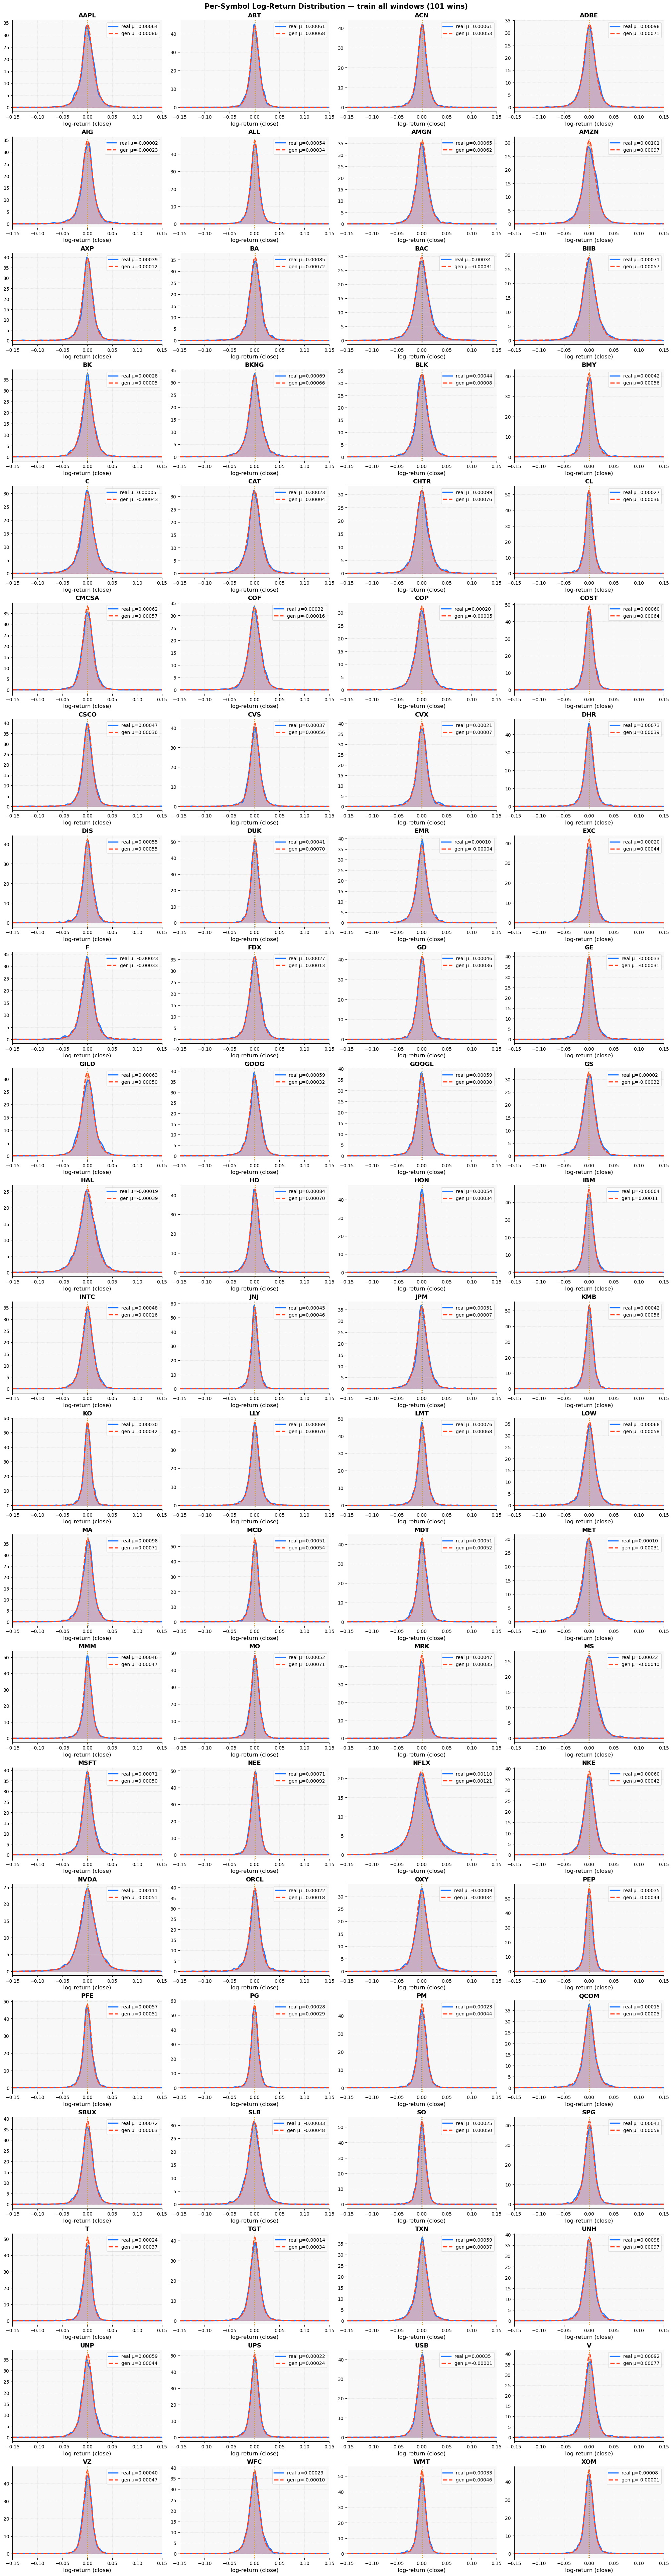


✓ saved → /home/narodom.y@FUSION.LAB/research/02_experiments/sp_index/sp_idx100/v1_trial01_w20a88_ddpm_warmup-cosine_optuna/simulations/train_all_n100/dist_per_symbol.png


In [17]:
n_assets = len(tickers)
ncols    = 4
nrows    = math.ceil(n_assets / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5), constrained_layout=True)
axes = np.atleast_1d(axes).flatten()

print(f"{'symbol':<12} {'real_μ':>9} {'real_σ':>9} {'gen_μ':>9} {'gen_σ':>9}  {'Δμ':>8}  {'Δσ':>8}")
print("-" * 70)

for a in range(n_assets):
    sym = tickers[a]
    r_a = log_ret_real_all[:, :, a, CLOSE_IDX].flatten()      # (n_ok*W,)
    g_a = log_ret_gen_all[:, :, :, a, CLOSE_IDX].flatten()    # (n_ok*N*W,)

    plot_log_return_dist(r_a, g_a, title=sym, clip=0.15, ax=axes[a])

    dm   = g_a.mean() - r_a.mean()
    ds   = g_a.std()  - r_a.std()
    flag = "  ⚠️" if abs(dm) > 0.005 or abs(ds) > 0.005 else ""
    print(f"{sym:<12} {r_a.mean():>+9.5f} {r_a.std():>9.5f} {g_a.mean():>+9.5f} {g_a.std():>9.5f}  {dm:>+8.5f}  {ds:>+8.5f}{flag}")

for j in range(n_assets, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"Per-Symbol Log-Return Distribution — {SPLIT} all windows ({n_ok} wins)",
    fontsize=15, fontweight="bold",
)
fig.savefig(sim_dir / "dist_per_symbol.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✓ saved → {sim_dir / 'dist_per_symbol.png'}")


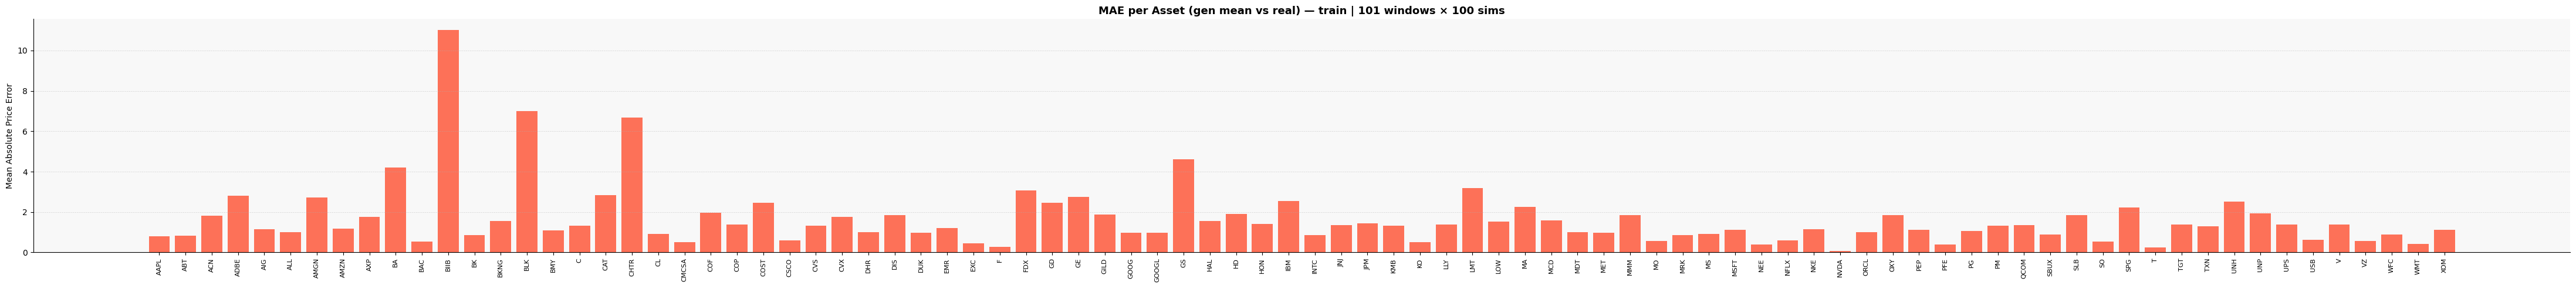

  ✓ saved → /home/narodom.y@FUSION.LAB/research/02_experiments/sp_index/sp_idx100/v1_trial01_w20a88_ddpm_warmup-cosine_optuna/simulations/train_all_n100/mae_per_asset.png


In [18]:
# ── Summary: MAE per asset (gen mean vs real, averaged across all windows) ──
prices_gen_mean = prices_gen_all.mean(axis=1)                           # (n_ok, W, A)
mae_per_asset   = np.abs(prices_gen_mean - prices_real_all).mean(axis=(0, 1))  # (A,)

fig, ax = plt.subplots(figsize=(max(10, len(tickers) * 0.5), 5))
ax.bar(range(len(tickers)), mae_per_asset, color="#ff4422", alpha=0.75)
ax.set_xticks(range(len(tickers)))
ax.set_xticklabels(tickers, rotation=90, fontsize=8)
ax.set_ylabel("Mean Absolute Price Error")
ax.set_title(
    f"MAE per Asset (gen mean vs real) — {SPLIT} | {n_ok} windows × {cfg.num_simulations} sims",
    fontsize=13, fontweight="bold",
)
ax.set_facecolor("#f8f8f8")
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(sim_dir / "mae_per_asset.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"  ✓ saved → {sim_dir / 'mae_per_asset.png'}")


# 8. Cross-Asset Correlation — Gen vs Real

เช็คว่า gen เรียนรู้ "ความสัมพันธ์ระหว่าง asset" (correlation structure) ได้ใกล้เคียง real แค่ไหน
- ค่าระหว่าง **-1 ถึง 1**: +1 = เคลื่อนไหวไปทางเดียวกันสมบูรณ์, -1 = สวนทางกันสมบูรณ์, 0 = ไม่สัมพันธ์กัน
- เทียบ corr matrix ของ `real` กับ `gen` (เฉลี่ยรวมทุก simulation และทุก window) แล้วดู diff ว่าโมเดลพลาดคู่ asset ไหนเยอะสุด
- ใช้ **lower triangle** เท่านั้น (ตัดซ้ำออก)


In [19]:
def compute_corr_matrix(log_returns: np.ndarray, close_idx: int) -> np.ndarray:
    """
    log_returns : (..., W, A, C_x) — รับได้ทั้ง real (W, A, C_x) และ gen (N, W, A, C_x)
                  ถ้ามีแกน N (หลาย simulation) จะรวม N กับ W เข้าด้วยกันก่อนคำนวณ
    close_idx   : index ของ channel "Close" ใน C_x
    return      : (A, A) — correlation matrix, ค่าอยู่ในช่วง [-1, 1]
    """
    lr_close = log_returns[..., close_idx]   # (..., W, A)
    A    = lr_close.shape[-1]
    flat = lr_close.reshape(-1, A)            # (n_obs, A)
    return np.corrcoef(flat, rowvar=False)    # (A, A)


def plot_corr_heatmaps(corr_real: np.ndarray, corr_gen: np.ndarray, tickers, save_path=None):
    """
    วาด 3 panel: real corr / gen corr / diff (gen - real)
    แสดงเฉพาะ lower triangle (ตัดส่วนซ้ำบน diagonal ออก)
    """
    A    = len(tickers)
    diff = corr_gen - corr_real

    # mask: True = upper triangle (จะ set เป็น NaN → ไม่แสดง)
    mask = np.triu(np.ones((A, A), dtype=bool), k=1)

    def apply_mask(mat):
        m = mat.copy().astype(float)
        m[mask] = np.nan
        return m

    fig, axes = plt.subplots(1, 3, figsize=(A * 0.9 + 6, A * 0.32 + 3))

    panels = [
        (apply_mask(corr_real), "Real",       axes[0], -1, 1,                       "RdBu_r"),
        (apply_mask(corr_gen),  "Gen",        axes[1], -1, 1,                       "RdBu_r"),
        (apply_mask(diff),      "Gen − Real", axes[2], -np.abs(diff).max(), np.abs(diff).max(), "RdBu_r"),
    ]

    for mat, title, ax, vmin, vmax, cmap in panels:
        im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap=cmap)
        ax.set_xticks(range(A))
        ax.set_yticks(range(A))
        ax.set_xticklabels(tickers, rotation=90, fontsize=8)
        ax.set_yticklabels(tickers, fontsize=8)
        ax.set_title(title, fontsize=13, fontweight="bold")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(
        f"Cross-Asset Correlation (Close log-return) — {SPLIT} all windows ({n_ok} wins × {cfg.num_simulations} sims)",
        fontsize=15, fontweight="bold",
    )
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  ✓ saved → {save_path}")
    plt.show()
    return diff


  ✓ saved → /home/narodom.y@FUSION.LAB/research/02_experiments/sp_index/sp_idx100/v1_trial01_w20a88_ddpm_warmup-cosine_optuna/simulations/train_all_n100/corr_matrix.png


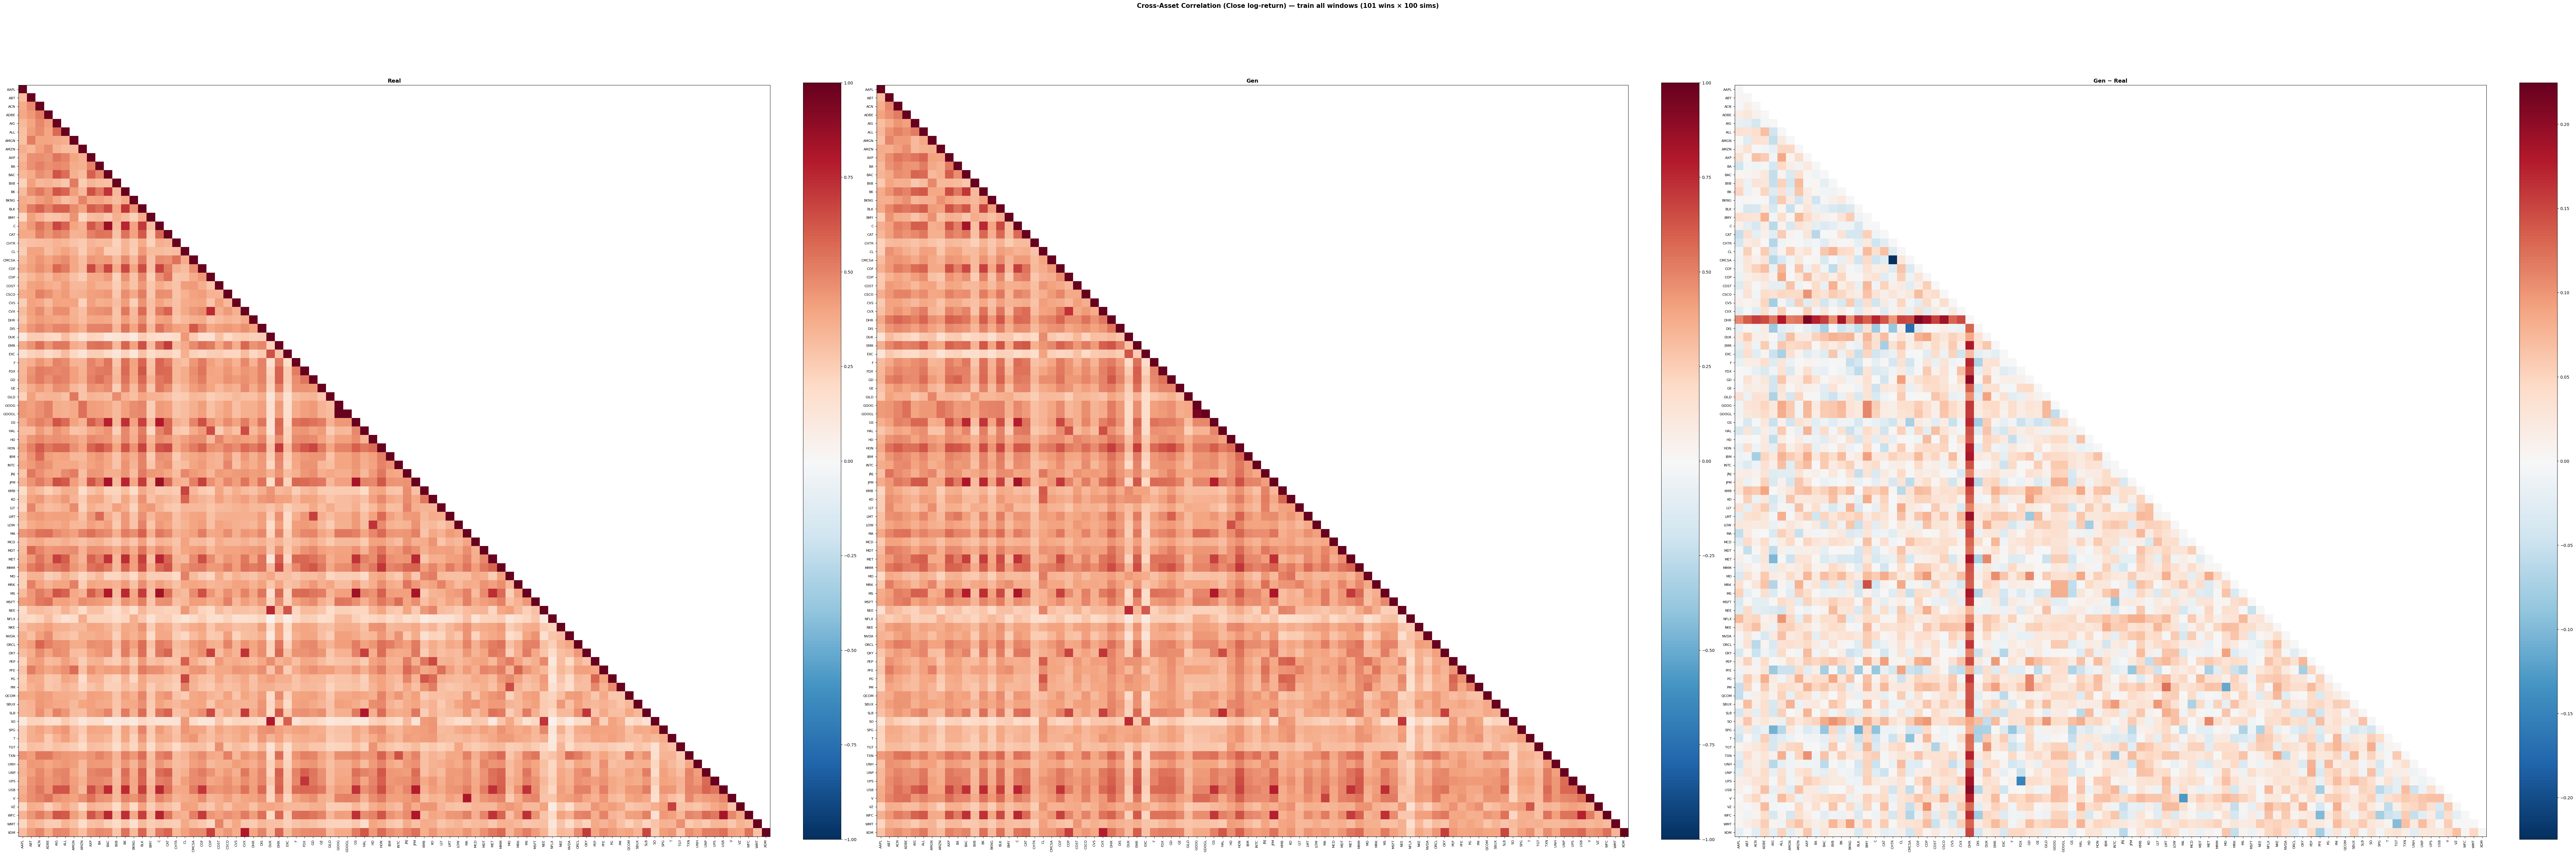

  mean |Δcorr| (lower triangle, off-diag) = 0.0338


In [20]:
corr_real = compute_corr_matrix(log_ret_real_all, CLOSE_IDX)   # (A, A)  รวมทุก window
corr_gen  = compute_corr_matrix(log_ret_gen_all,  CLOSE_IDX)   # (A, A)  รวมทุก window + sim

diff = plot_corr_heatmaps(
    corr_real, corr_gen, tickers,
    save_path=sim_dir / "corr_matrix.png",
)

mae = np.abs(diff[np.tril_indices(len(tickers), k=-1)]).mean()
print(f"  mean |Δcorr| (lower triangle, off-diag) = {mae:.4f}")
